In [139]:
import sys
import math
import matplotlib.pyplot as plt


In [140]:
def ler_tour_arquivo(caminho_arquivo):
    tour = []
    lendo = False

    with open(caminho_arquivo, 'r') as f:
        for linha in f:
            linha = linha.strip()

            if linha == "TOUR_SECTION":
                lendo = True
                continue

            if linha == "EOF":
                break

            if lendo:
                tour.append(int(linha))

    return tour

def ler_tsp_arquivo(caminho_arquivo):
    coords = []
    lendo = False

    with open(caminho_arquivo, 'r') as f:
        for linha in f:
            linha = linha.strip()

            if linha == "NODE_COORD_SECTION":
                lendo = True
                continue

            if linha == "EOF":
                break

            if lendo:
                partes = linha.split()
                id = int(partes[0])
                x = float(partes[1])
                y = float(partes[2])
                coords.append((id, x, y))

    return coords

def plotar_cidades(coords):
    xs = [c[1] for c in coords]
    ys = [c[2] for c in coords]

    plt.figure()
    plt.scatter(xs, ys)

    # Mostrar número da cidade
    for c in coords:
        plt.text(c[1], c[2], str(c[0]))

    plt.title("Cidades do TSP")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

def plotar_arestas(arestas, peso):
    plt.figure()

    for a in arestas:
        x1, y1 = a[1], a[2]
        x2, y2 = a[4], a[5]

        # desenha linha entre as cidades
        plt.plot([x1, x2], [y1, y2], marker='o')

        # desenha IDs das cidades
        plt.text(x1, y1, str(a[0]))
        plt.text(x2, y2, str(a[3]))

    plt.title(f"Caminho do Caixeiro Viajante (Vizinho Mais Próximo) (Peso = {peso})")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid()

    plt.show()

def plotar_caminho(coords, caminho, peso_otimizado):
    import matplotlib.pyplot as plt

    coords_dict = {c[0]: c for c in coords}

    xs = []
    ys = []

    for cidade in caminho:
        xs.append(coords_dict[cidade][1])
        ys.append(coords_dict[cidade][2])

    plt.figure(figsize=(10, 7))
    plt.plot(xs, ys, marker='o')

    for c in coords:
        plt.text(c[1], c[2], str(c[0]))

    plt.title(f"Caminho TSP com (Peso = {(peso_otimizado)})")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid()
    plt.show()


In [141]:

def calcular_distancia(cidade1, cidade2):
    _, xi, yi = cidade1
    _, xj, yj = cidade2

    dist = math.sqrt((xi - xj)**2 + (yi - yj)**2)
    return math.floor(0.5 + dist)

def calcular_peso_tour(tour, coords):
    coords_dict = {c[0]: c for c in coords}
    peso = 0

    for i in range(len(tour) - 1):
        a = coords_dict[tour[i]]
        b = coords_dict[tour[i+1]]
        peso += calcular_distancia(a, b)

    # fechar ciclo
    peso += calcular_distancia(coords_dict[tour[-1]], coords_dict[tour[0]])

    return peso
def vizinho_mais_proximo(coords):
    n = len(coords)
    visitado = [False] * n
    
    caminho = []
    arestas = []
    peso = 0

    atual = 0  # começa da primeira cidade
    visitado[atual] = True
    caminho.append(coords[atual][0])

    for _ in range(n - 1):
        melhor = None
        menor_dist = float('inf')

        for i in range(n):
            if not visitado[i]:
                d = calcular_distancia(coords[atual], coords[i])

                if d < menor_dist:
                    menor_dist = d
                    melhor = i

        # cidade atual e próxima
        cidade_atual = coords[atual]
        cidade_proxima = coords[melhor]

        # guarda a aresta
        arestas.append((
            cidade_atual[0], cidade_atual[1], cidade_atual[2],
            cidade_proxima[0], cidade_proxima[1], cidade_proxima[2],
            menor_dist
        ))

        peso += menor_dist
        atual = melhor
        visitado[atual] = True
        caminho.append(coords[atual][0])

    # FECHAR O CICLO (última cidade → primeira)
    cidade_final = coords[atual]
    cidade_inicial = coords[0]

    dist_final = calcular_distancia(cidade_final, cidade_inicial)

    arestas.append((
        cidade_final[0], cidade_final[1], cidade_final[2],
        cidade_inicial[0], cidade_inicial[1], cidade_inicial[2],
        dist_final
    ))

    peso += dist_final
    caminho.append(cidade_inicial[0]) 

    return caminho, arestas, peso

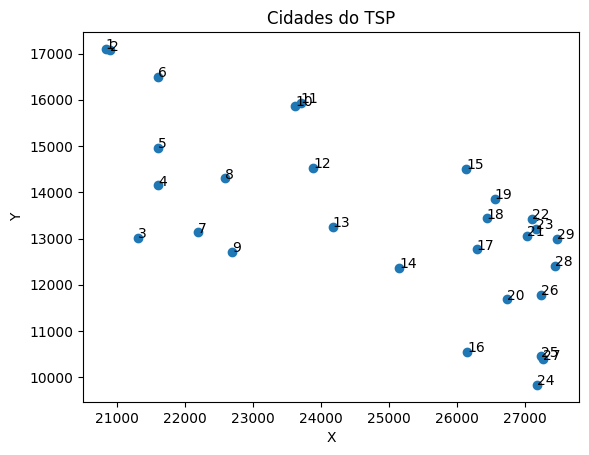

In [142]:
coords = ler_tsp_arquivo("tsp29.tsp")
plotar_cidades(coords)



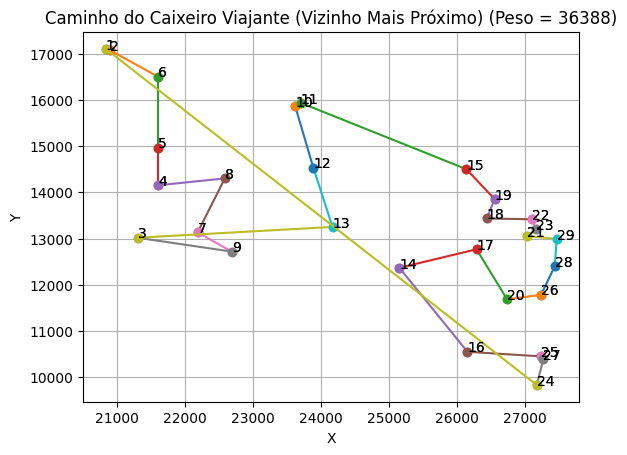

In [143]:
# Algoritmo guloso
caminho, arestas, peso = vizinho_mais_proximo(coords)
plotar_arestas(arestas, peso)


In [144]:
def calcular_custo_caminho(caminho, coords):
    coords_dict = {c[0]: c for c in coords}
    total = 0

    for i in range(len(caminho) - 1):
        a = coords_dict[caminho[i]]
        b = coords_dict[caminho[i+1]]
        total += calcular_distancia(a, b)

    return total

In [145]:
def two_opt_otimizado(caminho, coords):
    coords_dict = {c[0]: c for c in coords}

    def dist(a, b):
        return calcular_distancia(coords_dict[a], coords_dict[b])

    n = len(caminho)

    peso = 0
    for i in range(n):
        peso += dist(caminho[i], caminho[(i + 1) % n])

    melhorou = True

    while melhorou:
        melhorou = False

        for i in range(n - 1):
            for j in range(i + 2, n):

                if j == n - 1 and i == 0:
                    continue  # evita quebrar o ciclo

                A = caminho[i]
                B = caminho[i + 1]
                C = caminho[j]
                D = caminho[(j + 1) % n]

                # cálculo do ganho
                ganho = (dist(A, B) + dist(C, D)) - (dist(A, C) + dist(B, D))

                if ganho > 0:
                    # aplica a troca
                    caminho[i+1:j+1] = reversed(caminho[i+1:j+1])

                    peso -= ganho

                    melhorou = True

    return caminho, peso

Peso depois do 2-opt:->  27750


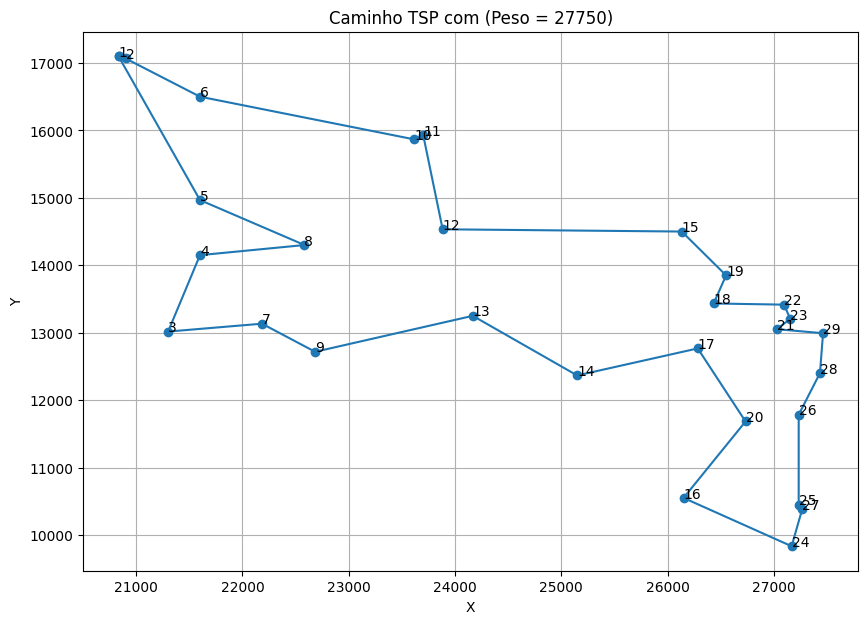

In [146]:
caminho_sem_retorno = caminho[:-1]

# aplica 2-opt
caminho_otimizado, peso_otimizado = two_opt_otimizado(caminho_sem_retorno, coords)

# fecha ciclo novamente
caminho_otimizado.append(caminho_otimizado[0])

print("Peso depois do 2-opt:-> ", peso_otimizado)

plotar_caminho(coords, caminho_otimizado, peso_otimizado)


In [147]:
def plotar_tour(coords, tour):
    coords_dict = {c[0]: c for c in coords}

    plt.figure(figsize=(10, 7))

    peso_total = 0

    for i in range(len(tour)):
        atual = tour[i]
        prox = tour[(i + 1) % len(tour)]

        x1, y1 = coords_dict[atual][1], coords_dict[atual][2]
        x2, y2 = coords_dict[prox][1], coords_dict[prox][2]

        dist = calcular_distancia(coords_dict[atual], coords_dict[prox])
        peso_total += dist

        # desenha linha
        plt.plot([x1, x2], [y1, y2])

        # escreve peso no meio
        xm = (x1 + x2) / 2
        ym = (y1 + y2) / 2
        plt.text(xm, ym, str(dist), fontsize=7)

    # desenhar pontos
    for c in coords:
        plt.scatter(c[1], c[2])
        plt.text(c[1], c[2], str(c[0]))

    plt.title(f"Tour Ótimo (Peso = {peso_total})")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid()

    plt.show()

Peso do tour ótimo: 27603


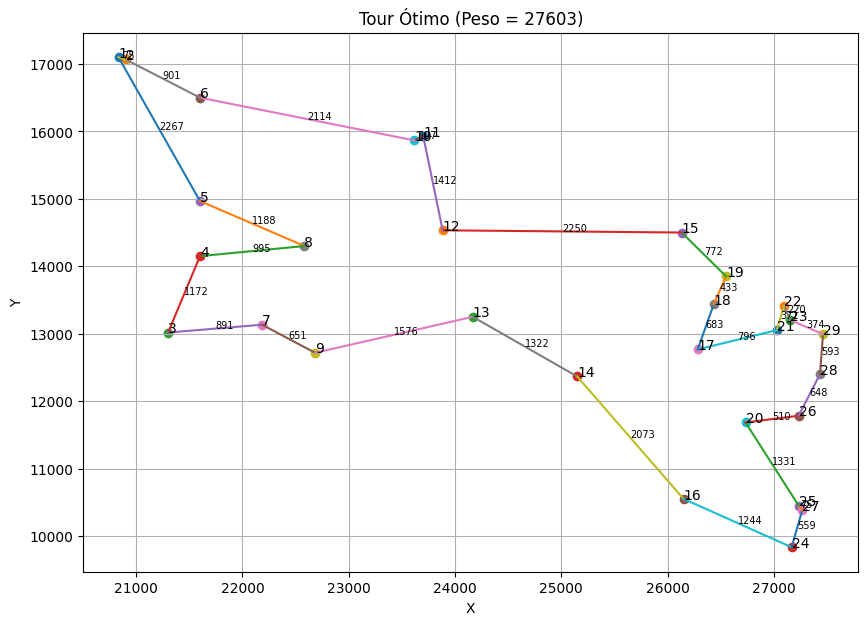

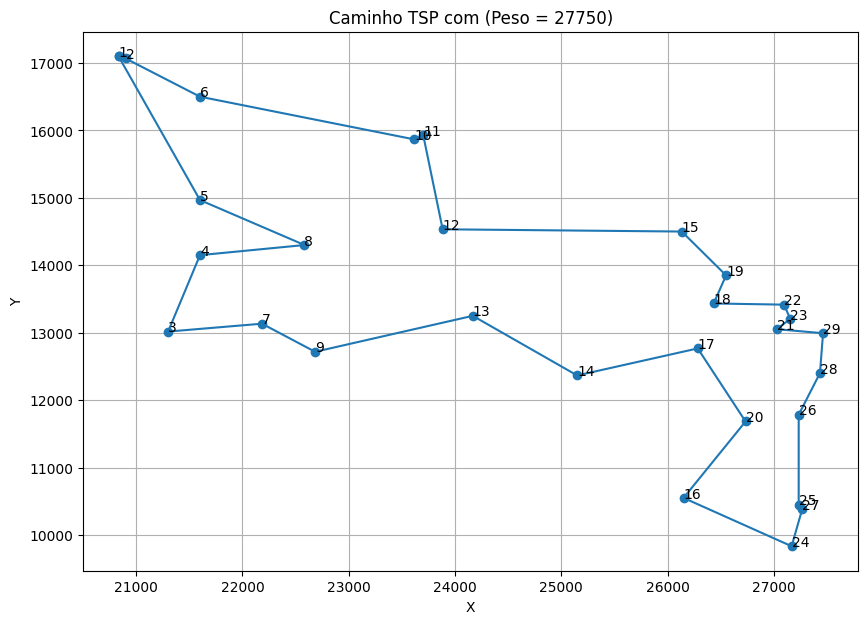

In [148]:
tour = ler_tour_arquivo("tsp29.tsp.tour")

peso_tour = calcular_peso_tour(tour, coords)

print("Peso do tour ótimo:", peso_tour)

plotar_tour(coords, tour)
plotar_caminho(coords, caminho_otimizado, peso_otimizado)
